# Model v1 — Fine-tuning Top Backbone Layers

**Difference from v0:** Instead of freezing the entire backbone and training only the linear head,
we unfreeze the top N feature-extraction blocks of EfficientNet-B0 and fine-tune them together
with the classifier head.

We train **three configurations**:
- **v1a** — unfreeze last 1 block  (features.8 = head conv + classifier)
- **v1b** — unfreeze last 2 blocks (features.7 + features.8 + classifier)
- **v1c** — unfreeze last 3 blocks (features.6 + features.7 + features.8 + classifier)

We use a **lower learning rate** for the unfrozen backbone layers (discriminative LR)
and a higher LR for the classifier head.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import json
import os

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available:  {torch.backends.mps.is_available()}")
print(f"PyTorch version: {torch.__version__}")

/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: False
MPS available:  True
PyTorch version: 2.11.0


In [2]:
from utils_2_dataloader import (
    ToothDataset, load_and_prepare_data, get_transforms, create_dataloaders,
    TOOTH_ID_TO_CLASS_NAME, IDX_TO_CLASS_NAME, CLASS_MAPPING_RULES,
    DATA_DIR, JSON_PATH, CLASS_NAMES
)

## Training & Validation Functions

In [3]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, accuracy, f1


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, accuracy, f1, all_preds, all_labels

## Model Factory — Partial Unfreezing

EfficientNet-B0 `features` is a `Sequential` with 9 children (indices 0..8):
- `features[0]` — initial Conv+BN
- `features[1..7]` — MBConv blocks (the main feature extraction)
- `features[8]` — final Conv+BN (head convolution)

We unfreeze from `features[unfreeze_from]` onwards, plus the classifier.

In [4]:
def get_model_v1(num_classes: int, unfreeze_from: int = 8, device: torch.device = None):
    """
    Creates EfficientNet-B0 with partial unfreezing.

    Args:
        num_classes: number of output classes.
        unfreeze_from: index of the first features block to unfreeze.
            8 = only head conv + classifier  (v1a)
            7 = last MBConv block + head conv + classifier  (v1b)
            6 = last 2 MBConv blocks + head conv + classifier  (v1c)
        device: target device.

    Returns:
        model, backbone_params (list), head_params (list)
    """
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze features[unfreeze_from:]
    num_feature_blocks = len(model.features)
    for i in range(unfreeze_from, num_feature_blocks):
        for param in model.features[i].parameters():
            param.requires_grad = True

    # Unfreeze classifier (always)
    for param in model.classifier.parameters():
        param.requires_grad = True

    # Separate parameter groups for discriminative LR
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("classifier"):
            head_params.append(param)
        else:
            backbone_params.append(param)

    # Summary
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params:     {total:,}")
    print(f"  Trainable params: {trainable:,} ({trainable/total*100:.1f}%)")
    print(f"  Backbone trainable: {sum(p.numel() for p in backbone_params):,}")
    print(f"  Head trainable:     {sum(p.numel() for p in head_params):,}")

    if device is not None:
        model = model.to(device)

    return model, backbone_params, head_params

## Configuration

In [5]:
# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
EPOCHS = 15  # more epochs since we're fine-tuning backbone layers
IMG_SIZE = 224

# Discriminative learning rates
HEAD_LR = 1e-3
BACKBONE_LR = 1e-4  # 10x smaller for pretrained layers

print(f"Using device: {DEVICE}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Class names: {CLASS_NAMES}")

Using device: mps
Num classes: 4
Class names: ['incisor', 'canine', 'premolar', 'molar']


In [6]:
# Load data (shared across all experiments)
print("Loading DataLoaders...")
train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=BATCH_SIZE,
    num_workers=4,
)

Loading DataLoaders...
Всего валидных сэмплов: 3584
  incisor: 520 (14.5%)
  canine: 254 (7.1%)
  premolar: 1140 (31.8%)
  molar: 1670 (46.6%)
Разбивка -> Train: 2508, Val: 538, Test: 538


/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Training Loop (reusable)

In [7]:
def run_experiment(
    experiment_name: str,
    unfreeze_from: int,
    epochs: int = EPOCHS,
    head_lr: float = HEAD_LR,
    backbone_lr: float = BACKBONE_LR,
    weight_decay: float = 1e-4,
):
    """
    Runs a full training experiment and returns history + test results.
    Saves the best model checkpoint and training history to disk.
    """
    print(f"\n{'='*60}")
    print(f"  Experiment: {experiment_name}")
    print(f"  Unfreeze from features[{unfreeze_from}:]")
    print(f"  Head LR: {head_lr}, Backbone LR: {backbone_lr}")
    print(f"{'='*60}\n")

    # Create model
    model, backbone_params, head_params = get_model_v1(
        NUM_CLASSES, unfreeze_from=unfreeze_from, device=DEVICE
    )

    # Criterion
    criterion = nn.CrossEntropyLoss()

    # Optimizer with discriminative LR
    param_groups = [
        {"params": head_params, "lr": head_lr},
    ]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": backbone_lr})

    optimizer = optim.Adam(param_groups, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    # Training
    best_val_f1 = 0.0
    checkpoint_path = f"best_{experiment_name}.pth"
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': [],
    }

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        val_loss, val_acc, val_f1, _, _ = validate_epoch(
            model, val_loader, criterion, DEVICE
        )
        scheduler.step(val_loss)

        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"  Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  >> New best model saved (Val F1: {best_val_f1:.4f})")

        print("-" * 40)

    # Final test evaluation
    print(f"\nLoading best checkpoint for {experiment_name}...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    test_loss, test_acc, test_f1, y_pred, y_true = validate_epoch(
        model, test_loader, criterion, DEVICE
    )

    print(f"\n=== {experiment_name} — FINAL TEST RESULTS ===")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"F1 Score (weighted): {test_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Save history to JSON for later comparison
    results = {
        'experiment_name': experiment_name,
        'unfreeze_from': unfreeze_from,
        'head_lr': head_lr,
        'backbone_lr': backbone_lr,
        'epochs': epochs,
        'best_val_f1': best_val_f1,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'history': history,
        'y_pred': [int(x) for x in y_pred],
        'y_true': [int(x) for x in y_true],
    }

    results_path = f"results_{experiment_name}.json"
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Results saved to {results_path}")

    return results

## Experiment v1a — Unfreeze last 1 block (features[8] + classifier)

This is the lightest fine-tuning: only the final head convolution layer and the classifier are trained.

In [8]:
results_v1a = run_experiment(
    experiment_name="v1a_unfreeze1",
    unfreeze_from=8,
)


  Experiment: v1a_unfreeze1
  Unfreeze from features[8:]
  Head LR: 0.001, Backbone LR: 0.0001

  Total params:     4,012,672
  Trainable params: 417,284 (10.4%)
  Backbone trainable: 412,160
  Head trainable:     5,124
Epoch 1/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.47s/it]


  Train Loss: 1.0028, Acc: 0.5993, F1: 0.5588
  Val   Loss: 0.7125, Acc: 0.7565, F1: 0.7259
  >> New best model saved (Val F1: 0.7259)
----------------------------------------
Epoch 2/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.42s/it]


  Train Loss: 0.7850, Acc: 0.7045, F1: 0.6891
  Val   Loss: 0.5689, Acc: 0.7937, F1: 0.7827
  >> New best model saved (Val F1: 0.7827)
----------------------------------------
Epoch 3/15


...

  Train Loss: 0.4942, Acc: 0.8082, F1: 0.8058
  Val   Loss: 0.2695, Acc: 0.9108, F1: 0.9084
  >> New best model saved (Val F1: 0.9084)
----------------------------------------
Epoch 15/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.41s/it]


  Train Loss: 0.4562, Acc: 0.8218, F1: 0.8198
  Val   Loss: 0.2712, Acc: 0.9089, F1: 0.9068
----------------------------------------

Loading best checkpoint for v1a_unfreeze1...


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.43s/it]



=== v1a_unfreeze1 — FINAL TEST RESULTS ===
Accuracy: 0.8922
F1 Score (weighted): 0.8913

Classification Report:
              precision    recall  f1-score   support

     incisor       0.82      0.77      0.79        78
      canine       0.91      0.79      0.85        38
    premolar       0.89      0.91      0.90       171
       molar       0.91      0.93      0.92       251

    accuracy                           0.89       538
   macro avg       0.88      0.85      0.87       538
weighted avg       0.89      0.89      0.89       538

Results saved to results_v1a_unfreeze1.json


## Experiment v1b — Unfreeze last 2 blocks (features[7:] + classifier)

We unfreeze the last MBConv block plus the head convolution.

In [9]:
results_v1b = run_experiment(
    experiment_name="v1b_unfreeze2",
    unfreeze_from=7,
)


  Experiment: v1b_unfreeze2
  Unfreeze from features[7:]
  Head LR: 0.001, Backbone LR: 0.0001

  Total params:     4,012,672
  Trainable params: 1,134,516 (28.3%)
  Backbone trainable: 1,129,392
  Head trainable:     5,124
Epoch 1/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.41s/it]


  Train Loss: 0.9407, Acc: 0.6180, F1: 0.5816
  Val   Loss: 0.6251, Acc: 0.7770, F1: 0.7478
  >> New best model saved (Val F1: 0.7478)
----------------------------------------
Epoch 2/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.41s/it]


  Train Loss: 0.6926, Acc: 0.7329, F1: 0.7207
  Val   Loss: 0.4723, Acc: 0.8327, F1: 0.8221
  >> New best model saved (Val F1: 0.8221)
----------------------------------------
Epoch 3/15


...

  Train Loss: 0.2968, Acc: 0.8812, F1: 0.8808
  Val   Loss: 0.1665, Acc: 0.9405, F1: 0.9399
  >> New best model saved (Val F1: 0.9399)
----------------------------------------
Epoch 15/15


Validating: 100%|██████████| 17/17 [00:23<00:00,  1.41s/it]


  Train Loss: 0.3206, Acc: 0.8764, F1: 0.8756
  Val   Loss: 0.1660, Acc: 0.9442, F1: 0.9447
  >> New best model saved (Val F1: 0.9447)
----------------------------------------

Loading best checkpoint for v1b_unfreeze2...


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.43s/it]



=== v1b_unfreeze2 — FINAL TEST RESULTS ===
Accuracy: 0.9182
F1 Score (weighted): 0.9193

Classification Report:
              precision    recall  f1-score   support

     incisor       0.74      0.86      0.80        78
      canine       0.91      0.76      0.83        38
    premolar       0.94      0.95      0.95       171
       molar       0.97      0.94      0.95       251

    accuracy                           0.92       538
   macro avg       0.89      0.88      0.88       538
weighted avg       0.92      0.92      0.92       538

Results saved to results_v1b_unfreeze2.json


## Experiment v1c — Unfreeze last 3 blocks (features[6:] + classifier)

More aggressive fine-tuning: the last two MBConv blocks plus the head convolution.

In [10]:
results_v1c = run_experiment(
    experiment_name="v1c_unfreeze3",
    unfreeze_from=6,
)


  Experiment: v1c_unfreeze3
  Unfreeze from features[6:]
  Head LR: 0.001, Backbone LR: 0.0001

  Total params:     4,012,672
  Trainable params: 3,160,864 (78.8%)
  Backbone trainable: 3,155,740
  Head trainable:     5,124
Epoch 1/15


Validating: 100%|██████████| 17/17 [00:48<00:00,  2.87s/it]


  Train Loss: 0.8693, Acc: 0.6372, F1: 0.6122
  Val   Loss: 0.4849, Acc: 0.8216, F1: 0.8095
  >> New best model saved (Val F1: 0.8095)
----------------------------------------
Epoch 2/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.42s/it]


  Train Loss: 0.5475, Acc: 0.7875, F1: 0.7798
  Val   Loss: 0.3120, Acc: 0.8755, F1: 0.8742
  >> New best model saved (Val F1: 0.8742)
----------------------------------------
Epoch 3/15


...

  Train Loss: 0.1652, Acc: 0.9434, F1: 0.9433
  Val   Loss: 0.0944, Acc: 0.9684, F1: 0.9682
----------------------------------------
Epoch 15/15


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.41s/it]


  Train Loss: 0.1589, Acc: 0.9426, F1: 0.9425
  Val   Loss: 0.0948, Acc: 0.9665, F1: 0.9664
----------------------------------------

Loading best checkpoint for v1c_unfreeze3...


Validating: 100%|██████████| 17/17 [00:24<00:00,  1.44s/it]



=== v1c_unfreeze3 — FINAL TEST RESULTS ===
Accuracy: 0.9498
F1 Score (weighted): 0.9493

Classification Report:
              precision    recall  f1-score   support

     incisor       0.91      0.86      0.88        78
      canine       0.94      0.87      0.90        38
    premolar       0.94      0.98      0.96       171
       molar       0.97      0.97      0.97       251

    accuracy                           0.95       538
   macro avg       0.94      0.92      0.93       538
weighted avg       0.95      0.95      0.95       538

Results saved to results_v1c_unfreeze3.json


## Quick Comparison of v1 Variants

In [11]:
# Summary table
print(f"{'Experiment':<25} {'Best Val F1':>12} {'Test Acc':>10} {'Test F1':>10}")
print("-" * 60)
for r in [results_v1a, results_v1b, results_v1c]:
    print(f"{r['experiment_name']:<25} {r['best_val_f1']:>12.4f} {r['test_acc']:>10.4f} {r['test_f1']:>10.4f}")

Experiment                 Best Val F1   Test Acc    Test F1
------------------------------------------------------------
v1a_unfreeze1                   0.9084     0.8922     0.8913
v1b_unfreeze2                   0.9447     0.9182     0.9193
v1c_unfreeze3                   0.9699     0.9498     0.9493


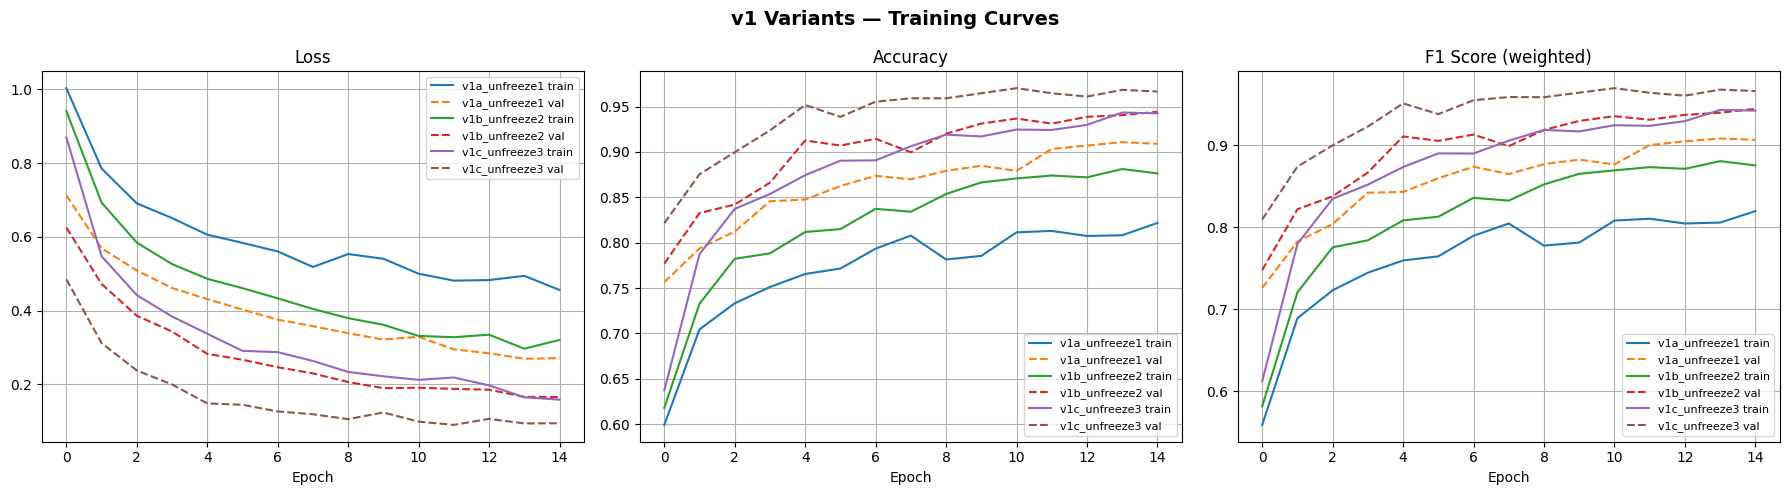

Plot saved as 'training_history_v1_all.png'


In [12]:
# Plot training curves for all v1 variants
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r in [results_v1a, results_v1b, results_v1c]:
    name = r['experiment_name']
    h = r['history']

    axes[0].plot(h['train_loss'], label=f"{name} train")
    axes[0].plot(h['val_loss'], '--', label=f"{name} val")

    axes[1].plot(h['train_acc'], label=f"{name} train")
    axes[1].plot(h['val_acc'], '--', label=f"{name} val")

    axes[2].plot(h['train_f1'], label=f"{name} train")
    axes[2].plot(h['val_f1'], '--', label=f"{name} val")

axes[0].set_title('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_title('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True)

axes[2].set_title('F1 Score (weighted)')
axes[2].legend(fontsize=8)
axes[2].grid(True)

for ax in axes:
    ax.set_xlabel('Epoch')

plt.suptitle('v1 Variants — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_history_v1_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'training_history_v1_all.png'")